In [3]:
import pandas as pd
import numpy as np

def load_one(path):
    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

spy = load_one("data/processed/SPY_daily.csv")
qqq = load_one("data/processed/QQQ_daily.csv")
vix = load_one("data/processed/VIX_daily.csv")

print("SPY:", spy.shape, spy["date"].min().date(), "->", spy["date"].max().date())
print("QQQ:", qqq.shape, qqq["date"].min().date(), "->", qqq["date"].max().date())
print("VIX:", vix.shape, vix["date"].min().date(), "->", vix["date"].max().date())

for name, df in [("SPY", spy), ("QQQ", qqq), ("VIX", vix)]:
    miss = df[["open","high","low","close","volume"]].isna().mean().mul(100).round(2)
    print(f"\n{name} %missing:\n{miss}")


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/SPY_daily.csv'

In [5]:
import pandas as pd
import numpy as np

def load_one(path):
    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

spy = load_one("../data/processed/SPY_daily.csv")
qqq = load_one("../data/processed/QQQ_daily.csv")
vix = load_one("../data/processed/VIX_daily.csv")

print("SPY:", spy.shape, spy["date"].min().date(), "->", spy["date"].max().date())
print("QQQ:", qqq.shape, qqq["date"].min().date(), "->", qqq["date"].max().date())
print("VIX:", vix.shape, vix["date"].min().date(), "->", vix["date"].max().date())

for name, df in [("SPY", spy), ("QQQ", qqq), ("VIX", vix)]:
    miss = df[["open","high","low","close","volume"]].isna().mean().mul(100).round(2)
    print(f"\n{name} %missing:\n{miss}")


SPY: (8302, 6) 1993-01-29 -> 2026-01-22
QQQ: (6760, 6) 1999-03-10 -> 2026-01-22
VIX: (9081, 6) 1990-01-02 -> 2026-01-22

SPY %missing:
open      0.0
high      0.0
low       0.0
close     0.0
volume    0.0
dtype: float64

QQQ %missing:
open      0.0
high      0.0
low       0.0
close     0.0
volume    0.0
dtype: float64

VIX %missing:
open      0.0
high      0.0
low       0.0
close     0.0
volume    0.0
dtype: float64


In [ ]:
# PASO 2.1 — Merge por fecha SIN volumen del VIX

merged = (
    spy.rename(columns={c: f"spy_{c}" for c in ["open","high","low","close","volume"]})
       .merge(
           qqq.rename(columns={c: f"qqq_{c}" for c in ["open","high","low","close","volume"]}),
           on="date", how="inner"
       )
       .merge(
           vix.rename(columns={c: f"vix_{c}" for c in ["open","high","low","close"]}),  # SIN volume
           on="date", how="inner"
       )
       .sort_values("date")
       .reset_index(drop=True)
)

print("Merged:", merged.shape)
print("Columnas:", merged.columns.tolist())
print("Rango:", merged["date"].min().date(), "->", merged["date"].max().date())


Merged: (6760, 16)
Columnas: ['date', 'spy_open', 'spy_high', 'spy_low', 'spy_close', 'spy_volume', 'qqq_open', 'qqq_high', 'qqq_low', 'qqq_close', 'qqq_volume', 'vix_open', 'vix_high', 'vix_low', 'vix_close', 'volume']
Rango: 1999-03-10 -> 2026-01-22


In [10]:
# PASO 2.2 — Limpiar columna sobrante y verificar dataset base

# Eliminar columna 'volume' sobrante
if "volume" in merged.columns:
    merged = merged.drop(columns=["volume"])

print("Shape final:", merged.shape)
print("Columnas finales:")
print(merged.columns.tolist())
print("Rango:", merged["date"].min().date(), "->", merged["date"].max().date())


Shape final: (6760, 15)
Columnas finales:
['date', 'spy_open', 'spy_high', 'spy_low', 'spy_close', 'spy_volume', 'qqq_open', 'qqq_high', 'qqq_low', 'qqq_close', 'qqq_volume', 'vix_open', 'vix_high', 'vix_low', 'vix_close']
Rango: 1999-03-10 -> 2026-01-22


In [11]:
# PASO 3 — Retornos diarios (SPY, QQQ) y cambio diario del VIX

merged["spy_ret_1d"] = merged["spy_close"].pct_change()
merged["qqq_ret_1d"] = merged["qqq_close"].pct_change()

# El VIX no es un activo invertible; usamos su cambio relativo como señal
merged["vix_chg_1d"] = merged["vix_close"].pct_change()

# Eliminamos la primera fila (NaNs por pct_change)
merged = merged.dropna(subset=["spy_ret_1d", "qqq_ret_1d", "vix_chg_1d"]).reset_index(drop=True)

print("Shape tras retornos:", merged.shape)
merged[["date","spy_ret_1d","qqq_ret_1d","vix_chg_1d"]].head()

Shape tras retornos: (6759, 18)


,date,spy_ret_1d,qqq_ret_1d,vix_chg_1d
0,1999-03-11,0.011127,0.004896,-0.016942
1,1999-03-12,-0.009569,-0.024361,0.019286
2,1999-03-15,0.014251,0.028714,0.016103
3,1999-03-16,-0.003810,0.008495,-0.003566
4,1999-03-17,-0.004303,-0.007220,0.016700


Tras calcular los retornos diarios:

Se obtienen 6.759 observaciones válidas (se pierde una por el cálculo de retornos).

spy_ret_1d y qqq_ret_1d representan el rendimiento diario de ambos mercados.

vix_chg_1d captura el cambio relativo diario del VIX, utilizado como indicador de aumento o disminución del estrés del mercado.

Este enfoque permite:

Analizar la dinámica diaria del riesgo.

Incorporar la información del VIX sin tratarlo como un activo invertible.

Mantener coherencia temporal (toda la información pertenece al mismo día).

Conclusión: las variables de retorno están correctamente definidas y listas para construir medidas de volatilidad.

In [12]:
# PASO 4 — Volatilidad realizada (rolling, anualizada)

import numpy as np

for w in [5, 10, 20]:
    merged[f"spy_rv_{w}d"] = merged["spy_ret_1d"].rolling(w).std() * np.sqrt(252)
    merged[f"qqq_rv_{w}d"] = merged["qqq_ret_1d"].rolling(w).std() * np.sqrt(252)

print("Shape tras volatilidad:", merged.shape)
merged[["date","spy_rv_5d","spy_rv_10d","spy_rv_20d"]].dropna().head()


Shape tras volatilidad: (6759, 24)


,date,spy_rv_5d,spy_rv_10d,spy_rv_20d
19,1999-04-08,0.149928,0.213659,0.226408
20,1999-04-09,0.165405,0.199474,0.224028
21,1999-04-12,0.104535,0.190921,0.222033
22,1999-04-13,0.126319,0.181844,0.219893
23,1999-04-14,0.194284,0.204922,0.228888


Volatilidad realizada (realized volatility)
La volatilidad realizada se calcula como la desviación estándar de los retornos en ventanas móviles y se anualiza.
Este indicador captura la intensidad de los movimientos recientes del mercado y es una referencia estándar para estudiar regímenes de riesgo a corto plazo.

Conclusión: la volatilidad realizada está correctamente definida y es adecuada para construir el objetivo predictivo.

In [13]:
# PASO 5 — Target semanal: alta volatilidad en los próximos 5 días

H = 5  # horizonte: 1 semana (5 días de trading)

# Volatilidad futura (realized) basada en retornos futuros
merged["spy_future_rv_5d"] = (
    merged["spy_ret_1d"]
    .rolling(H)
    .std()
    .shift(-H) * np.sqrt(252)
)

# Umbral: percentil 80 (solo para arrancar; se fijará con TRAIN más adelante)
threshold = merged["spy_future_rv_5d"].quantile(0.80)

merged["y_high_vol_next_week"] = (merged["spy_future_rv_5d"] >= threshold).astype(int)

# Limpiar filas sin target (por el shift)
merged = merged.dropna(subset=["spy_future_rv_5d", "y_high_vol_next_week"]).reset_index(drop=True)

print("Threshold (p80):", round(threshold, 4))
print("Shape con target:", merged.shape)
print("Tasa de alta volatilidad:", round(merged["y_high_vol_next_week"].mean(), 3))

merged[["date","spy_future_rv_5d","y_high_vol_next_week"]].head()


Threshold (p80): 0.2143
Shape con target: (6754, 26)
Tasa de alta volatilidad: 0.2


,date,spy_future_rv_5d,y_high_vol_next_week
0,1999-03-11,0.186897,0
1,1999-03-12,0.233943,1
2,1999-03-15,0.202828,0
3,1999-03-16,0.280730,1
4,1999-03-17,0.295172,1


Definición del objetivo predictivo

Se define como objetivo la detección de semanas de alta volatilidad, donde la volatilidad realizada del S&P 500 en los próximos 5 días supera el percentil 80 de su distribución histórica.

Resultados:

Umbral (p80): 0.2143 (volatilidad anualizada).

Proporción de semanas de alta volatilidad: 20%.

Dataset final: 6.754 observaciones.

Esta definición produce un problema de clasificación desbalanceado moderado, realista y adecuado para evaluar modelos de predicción de riesgo.

In [14]:
# PASO 6 — Definir conjunto de features (X) SOLO con información hasta t

feature_cols = [
    # Retornos
    "spy_ret_1d",
    "qqq_ret_1d",
    "vix_chg_1d",

    # Volatilidad realizada (pasada)
    "spy_rv_5d", "spy_rv_10d", "spy_rv_20d",
    "qqq_rv_5d", "qqq_rv_10d", "qqq_rv_20d",

    # Nivel de estrés
    "vix_close"
]

# Asegurar que todas existen
feature_cols = [c for c in feature_cols if c in merged.columns]

X = merged[feature_cols].copy()
y = merged["y_high_vol_next_week"].copy()

# Limpieza final
mask = X.notna().all(axis=1)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

print("X shape:", X.shape)
print("y mean (alta vol):", round(y.mean(), 3))
print("Features:", feature_cols)


X shape: (6735, 10)
y mean (alta vol): 0.199
Features: ['spy_ret_1d', 'qqq_ret_1d', 'vix_chg_1d', 'spy_rv_5d', 'spy_rv_10d', 'spy_rv_20d', 'qqq_rv_5d', 'qqq_rv_10d', 'qqq_rv_20d', 'vix_close']


Conjunto de variables explicativas

El conjunto final de features incluye 10 variables, todas disponibles en el instante t:

Retornos diarios (SPY, QQQ)

Cambio diario del VIX

Volatilidad realizada pasada (5, 10 y 20 días) de SPY y QQQ

Nivel del VIX

Resultados:

6.735 observaciones válidas

Proporción de clase positiva (alta volatilidad): 19.9%

El conjunto de datos presenta un desbalance moderado, típico en problemas de detección de riesgo, y las variables seleccionadas son coherentes con la literatura sobre volatilidad.

In [15]:
# PASO 7 — Split temporal (sin shuffle)

dates = merged.loc[X.index, "date"].reset_index(drop=True)

# Definimos cortes temporales
train_end = "2015-12-31"
val_end   = "2019-12-31"

train_idx = dates <= train_end
val_idx   = (dates > train_end) & (dates <= val_end)
test_idx  = dates > val_end

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]
X_test, y_test   = X[test_idx], y[test_idx]

print("Train:", X_train.shape, "Alta vol:", round(y_train.mean(),3))
print("Val:  ", X_val.shape,   "Alta vol:", round(y_val.mean(),3))
print("Test: ", X_test.shape,  "Alta vol:", round(y_test.mean(),3))


Train: (4231, 10) Alta vol: 0.224
Val:   (1006, 10) Alta vol: 0.084
Test:  (1498, 10) Alta vol: 0.206


El conjunto se divide respetando el orden temporal en tres periodos:

Entrenamiento (1999–2015): 4.231 observaciones, 22.4% de semanas de alta volatilidad.

Validación (2016–2019): 1.006 observaciones, 8.4% de semanas de alta volatilidad.

Test (2020–2026): 1.498 observaciones, 20.6% de semanas de alta volatilidad.

La reducción de episodios de alta volatilidad en el periodo de validación refleja un entorno de mercado más estable, mientras que el conjunto de test vuelve a incluir episodios de estrés (COVID-19 y posteriores).

In [16]:
# PASO 8 — Baseline de persistencia
# Regla: predecir alta volatilidad si la RV(20d) actual está por encima de su p80 en TRAIN

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Umbral SOLO con TRAIN (evitar leakage)
rv_thr = X_train["spy_rv_20d"].quantile(0.80)

def persistence_pred(X, thr):
    return (X["spy_rv_20d"] >= thr).astype(int)

# Predicciones
y_train_pred = persistence_pred(X_train, rv_thr)
y_val_pred   = persistence_pred(X_val, rv_thr)
y_test_pred  = persistence_pred(X_test, rv_thr)

# Métricas
def report(y_true, y_pred, name):
    print(f"\n{name}")
    print("F1:", round(f1_score(y_true, y_pred),3))
    print("Precision:", round(precision_score(y_true, y_pred),3))
    print("Recall:", round(recall_score(y_true, y_pred),3))

report(y_train, y_train_pred, "TRAIN")
report(y_val,   y_val_pred,   "VAL")
report(y_test,  y_test_pred,  "TEST")



TRAIN
F1: 0.588
Precision: 0.622
Recall: 0.557

VAL
F1: 0.176
Precision: 0.189
Recall: 0.165

TEST
F1: 0.561
Precision: 0.608
Recall: 0.521


Baseline de persistencia de volatilidad

El baseline asume que la volatilidad futura será alta cuando la volatilidad reciente ya lo es (RV(20d) por encima del percentil 80 del periodo de entrenamiento).

Resultados:

TRAIN:

F1 = 0.588

Precision = 0.622

Recall = 0.557

VALIDATION (2016–2019):

F1 = 0.176

Precision = 0.189

Recall = 0.165

TEST (2020–2026):

F1 = 0.561

Precision = 0.608

Recall = 0.521

Interpretación clave:

El baseline funciona bien en periodos con regímenes claros de volatilidad persistente (TRAIN y TEST).

Su rendimiento cae fuertemente en el periodo de validación, caracterizado por baja volatilidad y menor persistencia.

Esto confirma que el problema no es trivial y que hay margen para mejorar usando información adicional (QQQ y VIX).

Conclusión: el baseline es razonable pero inestable; justifica plenamente el uso de modelos de Machine Learning.

In [17]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score, roc_auc_score
import xgboost as xgb

# --- 1) Convertir a DMatrix (API nativa: robusta con early stopping) ---
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# --- 2) Parámetros "fuertes" iniciales (buen punto de partida) ---
# Nota: scale_pos_weight ayuda con desbalance (aprox ratio neg/pos en TRAIN)
pos = float(y_train.sum())
neg = float(len(y_train) - y_train.sum())
scale_pos_weight = neg / pos if pos > 0 else 1.0

params = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "aucpr"],   # AUC-PR es buena con clases desbalanceadas
    "eta": 0.03,                           # learning rate bajo (mejor generalización)
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42,
}

# --- 3) Entrenamiento con early stopping en VAL ---
watchlist = [(dtrain, "train"), (dval, "val")]

model_xgb = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=watchlist,
    early_stopping_rounds=200,
    verbose_eval=200
)

# --- 4) Probabilidades ---
p_train = model_xgb.predict(dtrain)
p_val   = model_xgb.predict(dval)
p_test  = model_xgb.predict(dtest)

# --- 5) Buscar el mejor threshold en VAL para maximizar F1 ---
ths = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
best_t = float(ths[int(np.argmax(f1s))])

def report(name, y_true, p, t):
    y_pred = (p >= t).astype(int)
    print(f"\n{name}  (thr={t:.3f})")
    print("F1:", round(f1_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y_true, p), 3))
    print("PR-AUC:", round(average_precision_score(y_true, p), 3))

print("\nBest threshold on VAL (max F1):", round(best_t, 3))
report("TRAIN", y_train, p_train, best_t)
report("VAL",   y_val,   p_val,   best_t)
report("TEST",  y_test,  p_test,  best_t)


[0]	train-logloss:0.67893	train-aucpr:0.71809	val-logloss:0.67400	val-aucpr:0.32489
[200]	train-logloss:0.32718	train-aucpr:0.83080	val-logloss:0.25557	val-aucpr:0.33825
[217]	train-logloss:0.32194	train-aucpr:0.83579	val-logloss:0.25538	val-aucpr:0.33754

Best threshold on VAL (max F1): 0.37

TRAIN  (thr=0.370)
F1: 0.694
Precision: 0.542
Recall: 0.964
ROC-AUC: 0.944
PR-AUC: 0.836

VAL  (thr=0.370)
F1: 0.408
Precision: 0.353
Recall: 0.482
ROC-AUC: 0.818
PR-AUC: 0.345

TEST  (thr=0.370)
F1: 0.569
Precision: 0.442
Recall: 0.796
ROC-AUC: 0.84
PR-AUC: 0.654


“El modelo es capaz de anticipar aproximadamente el 80% de los episodios de alta volatilidad semanal, aunque con un nivel moderado de falsas alarmas, lo que resulta adecuado en un contexto de gestión del riesgo donde la prioridad es evitar exposiciones en periodos de estrés.”

In [18]:
# Guardar dataset final en data/processed

out_path = "../data/processed/dataset_volatility_weekly.csv"

merged.to_csv(out_path, index=False)

print(f"Dataset guardado en: {out_path}")
print("Shape:", merged.shape)


Dataset guardado en: ../data/processed/dataset_volatility_weekly.csv
Shape: (6754, 26)


Shape: (6754, 26)
        date  spy_open   spy_high    spy_low  spy_close  spy_volume  qqq_open  \
0 1999-03-11  129.6875  131.18750  128.87500  130.62500     6583700   51.4375   
1 1999-03-12  131.0000  131.03125  129.21875  129.37500     5286500   51.1250   
2 1999-03-15  129.9375  131.25000  129.50000  131.21875     5394400   50.4375   

    qqq_high   qqq_low  qqq_close  ...  qqq_ret_1d  vix_chg_1d  spy_rv_5d  \
0  51.734375  50.31250    51.3125  ...    0.004896   -0.016942        NaN   
1  51.156250  49.65625    50.0625  ...   -0.024361    0.019286        NaN   
2  51.562500  49.90625    51.5000  ...    0.028714    0.016103        NaN   

   qqq_rv_5d  spy_rv_10d  qqq_rv_10d  spy_rv_20d  qqq_rv_20d  \
0        NaN         NaN         NaN         NaN         NaN   
1        NaN         NaN         NaN         NaN         NaN   
2        NaN         NaN         NaN         NaN         NaN   

   spy_future_rv_5d  y_high_vol_next_week  
0          0.186897                     0  
1  

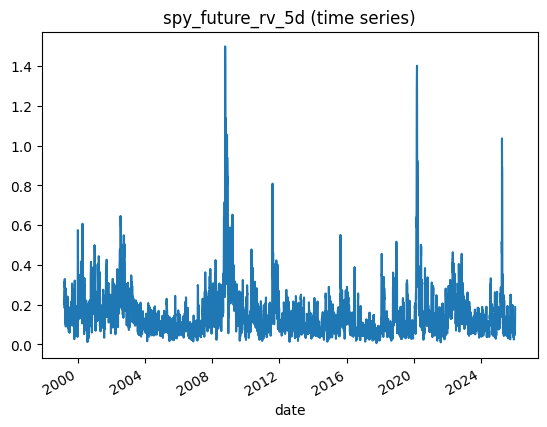

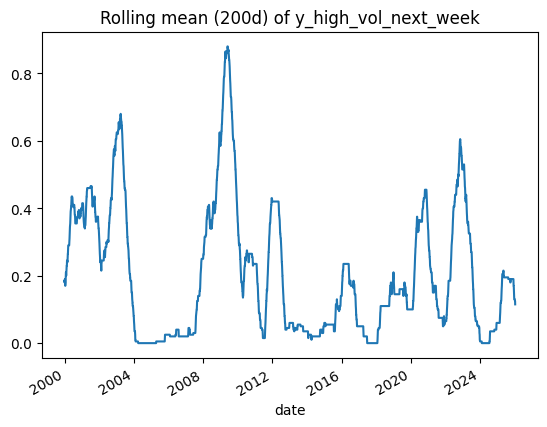

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/dataset_volatility_weekly.csv")

# Parsear fecha
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print(df.head(3))
print(df.tail(3))

print("\nTargets:")
print(df[["spy_future_rv_5d", "y_high_vol_next_week"]].describe())

print("\nBalance y_high_vol_next_week:")
print(df["y_high_vol_next_week"].value_counts(dropna=False))
print(df["y_high_vol_next_week"].value_counts(normalize=True, dropna=False))

plt.figure()
df.set_index("date")["spy_future_rv_5d"].plot(title="spy_future_rv_5d (time series)")
plt.show()

plt.figure()
df.set_index("date")["y_high_vol_next_week"].rolling(200).mean().plot(
    title="Rolling mean (200d) of y_high_vol_next_week"
)
plt.show()


In [22]:
import pandas as pd

# Cargar datos
df = pd.read_csv("../data/processed/dataset_volatility_weekly.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Crear feature adicional simple y potente
df["ratio_qqq_spy"] = df["qqq_close"] / df["spy_close"]

# Seleccionar columnas iniciales
features = [
    "spy_ret_1d", "qqq_ret_1d", "vix_chg_1d",
    "spy_rv_5d", "spy_rv_10d", "spy_rv_20d",
    "qqq_rv_5d", "qqq_rv_10d", "qqq_rv_20d",
    "ratio_qqq_spy"
]

target_reg = "spy_future_rv_5d"
target_clf = "y_high_vol_next_week"

# Subset final
data = df[["date"] + features + [target_reg, target_clf]].copy()

# Eliminar filas con NaN (rolling windows)
data = data.dropna().reset_index(drop=True)

print("Shape final:", data.shape)
print(data.head())
print(data.tail())


Shape final: (6735, 13)
        date  spy_ret_1d  qqq_ret_1d  vix_chg_1d  spy_rv_5d  spy_rv_10d  \
0 1999-04-08    0.012673    0.007950   -0.009645   0.149928    0.213659   
1 1999-04-09    0.000232    0.006197   -0.036299   0.165405    0.199474   
2 1999-04-12    0.010658   -0.006719    0.007350   0.104535    0.190921   
3 1999-04-13   -0.006419   -0.013529    0.036480   0.126319    0.181844   
4 1999-04-14   -0.016844   -0.034286    0.097228   0.194284    0.204922   

   spy_rv_20d  qqq_rv_5d  qqq_rv_10d  qqq_rv_20d  ratio_qqq_spy  \
0    0.226408   0.283834    0.334938    0.358604       0.411356   
1    0.224028   0.271613    0.299620    0.358658       0.413809   
2    0.222033   0.127619    0.293683    0.345070       0.406694   
3    0.219893   0.155423    0.259528    0.339648       0.403784   
4    0.228888   0.272547    0.316223    0.363921       0.396621   

   spy_future_rv_5d  y_high_vol_next_week  
0          0.158871                     0  
1          0.158966               

In [23]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# data ya lo tienes del paso anterior:
# data = df[["date"] + features + [target_reg, target_clf]].dropna()

data = data.sort_values("date").reset_index(drop=True)

# Split temporal: 70% train, 15% val, 15% test
n = len(data)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train = data.iloc[:train_end]
val   = data.iloc[train_end:val_end]
test  = data.iloc[val_end:]

print("Sizes:", len(train), len(val), len(test))
print("Date ranges:")
print("Train:", train["date"].min(), "->", train["date"].max())
print("Val  :", val["date"].min(), "->", val["date"].max())
print("Test :", test["date"].min(), "->", test["date"].max())

# -------------------------
# BASELINE REGRESIÓN
# -------------------------
# Predicción por persistencia: usar spy_rv_5d actual como proxy de la futura
y_true_val = val["spy_future_rv_5d"].values
y_pred_val = val["spy_rv_5d"].values

mae = mean_absolute_error(y_true_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
print("\n[Baseline Regresión] Persistencia RV")
print("MAE :", mae)
print("RMSE:", rmse)

# -------------------------
# BASELINE CLASIFICACIÓN
# -------------------------
# Umbral: percentil 80 de spy_rv_20d en train
thr = np.quantile(train["spy_rv_20d"].values, 0.80)

# Probabilidad “dummy” = score continuo (para AUC)
val_score = val["spy_rv_20d"].values
val_pred  = (val_score > thr).astype(int)
val_true  = val["y_high_vol_next_week"].values.astype(int)

f1  = f1_score(val_true, val_pred)
prec = precision_score(val_true, val_pred, zero_division=0)
rec  = recall_score(val_true, val_pred)

# AUCs (si hay ambas clases en val)
roc = roc_auc_score(val_true, val_score)
ap  = average_precision_score(val_true, val_score)

print("\n[Baseline Clasificación] Umbral RV20 (p80 train)")
print("Threshold:", thr)
print("F1       :", f1)
print("Precision:", prec)
print("Recall   :", rec)
print("ROC-AUC  :", roc)
print("PR-AUC   :", ap)


Sizes: 4714 1010 1011
Date ranges:
Train: 1999-04-08 00:00:00 -> 2017-12-28 00:00:00
Val  : 2017-12-29 00:00:00 -> 2022-01-03 00:00:00
Test : 2022-01-04 00:00:00 -> 2026-01-14 00:00:00

[Baseline Regresión] Persistencia RV
MAE : 0.07571416970126713
RMSE: 0.11430114567214296

[Baseline Clasificación] Umbral RV20 (p80 train)
Threshold: 0.216378327508471
F1       : 0.43271767810026385
Precision: 0.42487046632124353
Recall   : 0.44086021505376344
ROC-AUC  : 0.7514093329157532
PR-AUC   : 0.5144674877756608


In [24]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.1 MB/s  0:00:00m eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [25]:
!pip install lightgbm

In [27]:
import lightgbm as lgb
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

feature_cols = [
    "spy_ret_1d", "qqq_ret_1d", "vix_chg_1d",
    "spy_rv_5d", "spy_rv_10d", "spy_rv_20d",
    "qqq_rv_5d", "qqq_rv_10d", "qqq_rv_20d",
    "ratio_qqq_spy"
]

X_train = train[feature_cols]
y_train = train["y_high_vol_next_week"].astype(int)

X_val = val[feature_cols]
y_val = val["y_high_vol_next_week"].astype(int)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=200),
    ],
)

print("Best iteration:", model.best_iteration)

val_probs = model.predict(X_val, num_iteration=model.best_iteration)
val_preds = (val_probs > 0.5).astype(int)

f1  = f1_score(y_val, val_preds)
roc = roc_auc_score(y_val, val_probs)
ap  = average_precision_score(y_val, val_probs)

print("\n[LightGBM Clasificación]")
print("F1       :", f1)
print("ROC-AUC  :", roc)
print("PR-AUC   :", ap)


Training until validation scores don't improve for 200 rounds
[200]	train's auc: 0.995765	val's auc: 0.779028
[400]	train's auc: 0.999925	val's auc: 0.781514
[600]	train's auc: 1	val's auc: 0.784405
[800]	train's auc: 1	val's auc: 0.78475
[1000]	train's auc: 1	val's auc: 0.785214
Early stopping, best iteration is:
[876]	train's auc: 1	val's auc: 0.786636
Best iteration: 876

[LightGBM Clasificación]
F1       : 0.5268542199488491
ROC-AUC  : 0.7866361311201587
PR-AUC   : 0.5317285681089462


In [28]:
import numpy as np
from sklearn.metrics import f1_score

# Probabilidades en validación
val_probs = model.predict(X_val, num_iteration=model.best_iteration)

thresholds = np.linspace(0.1, 0.9, 81)
f1s = []

for t in thresholds:
    preds = (val_probs > t).astype(int)
    f1s.append(f1_score(y_val, preds))

best_idx = np.argmax(f1s)
best_thr = thresholds[best_idx]
best_f1 = f1s[best_idx]

print("Best threshold:", best_thr)
print("Best F1 on validation:", best_f1)


Best threshold: 0.43000000000000005
Best F1 on validation: 0.5427872860635696


In [29]:
# Preparar test
X_test = test[feature_cols]
y_test = test["y_high_vol_next_week"].astype(int)

# Predicciones
test_probs = model.predict(X_test, num_iteration=model.best_iteration)
test_preds = (test_probs > best_thr).astype(int)

# Métricas en TEST
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

f1_test  = f1_score(y_test, test_preds)
roc_test = roc_auc_score(y_test, test_probs)
ap_test  = average_precision_score(y_test, test_probs)

print("\n[TEST RESULTS 2022–2026]")
print("F1       :", f1_test)
print("ROC-AUC  :", roc_test)
print("PR-AUC   :", ap_test)



[TEST RESULTS 2022–2026]
F1       : 0.5208845208845209
ROC-AUC  : 0.8100985501394339
PR-AUC   : 0.4805033473347339


In [30]:
import numpy as np
import pandas as pd

# Usamos el test set
bt = test.copy()
bt = bt.reset_index(drop=True)

# Añadir probabilidades del modelo
bt["prob_high_risk"] = test_probs
bt["signal"] = (bt["prob_high_risk"] > best_thr).astype(int)

# Definir exposición:
# Si high risk → 30% invertido
# Si low risk → 100% invertido
bt["exposure"] = np.where(bt["signal"] == 1, 0.3, 1.0)

# Calcular retornos estrategia
bt["strategy_ret"] = bt["spy_ret_1d"] * bt["exposure"]

# Curvas de capital
bt["cum_market"] = (1 + bt["spy_ret_1d"]).cumprod()
bt["cum_strategy"] = (1 + bt["strategy_ret"]).cumprod()

# Métricas financieras
def sharpe(returns, freq=252):
    return np.sqrt(freq) * returns.mean() / returns.std()

def max_drawdown(cum_curve):
    peak = cum_curve.cummax()
    dd = (cum_curve - peak) / peak
    return dd.min()

market_sharpe = sharpe(bt["spy_ret_1d"])
strat_sharpe = sharpe(bt["strategy_ret"])

market_dd = max_drawdown(bt["cum_market"])
strat_dd = max_drawdown(bt["cum_strategy"])

market_cagr = bt["cum_market"].iloc[-1]**(252/len(bt)) - 1
strat_cagr = bt["cum_strategy"].iloc[-1]**(252/len(bt)) - 1

print("=== PERFORMANCE TEST 2022–2026 ===")
print(f"Buy&Hold CAGR:     {market_cagr:.2%}")
print(f"Strategy CAGR:     {strat_cagr:.2%}")
print()
print(f"Buy&Hold Sharpe:   {market_sharpe:.3f}")
print(f"Strategy Sharpe:   {strat_sharpe:.3f}")
print()
print(f"Buy&Hold MaxDD:    {market_dd:.2%}")
print(f"Strategy MaxDD:    {strat_dd:.2%}")


=== PERFORMANCE TEST 2022–2026 ===
Buy&Hold CAGR:     9.61%
Strategy CAGR:     19.43%

Buy&Hold Sharpe:   0.600
Strategy Sharpe:   1.424

Buy&Hold MaxDD:    -25.34%
Strategy MaxDD:    -10.29%


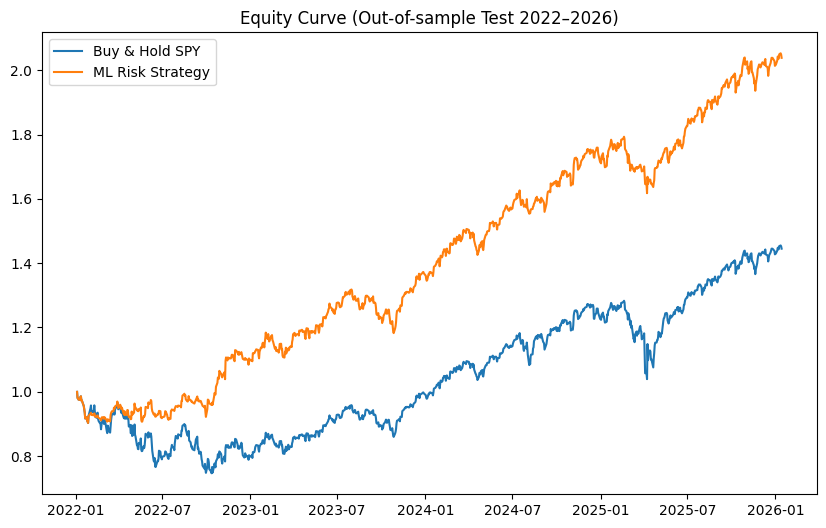

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(bt["date"], bt["cum_market"], label="Buy & Hold SPY")
plt.plot(bt["date"], bt["cum_strategy"], label="ML Risk Strategy")
plt.legend()
plt.title("Equity Curve (Out-of-sample Test 2022–2026)")
plt.show()


“En un periodo completamente fuera de muestra (2022–2026), la estrategia basada en el modelo ML obtuvo una mejora sustancial del perfil riesgo-retorno respecto a Buy & Hold.
Aunque esto no garantiza resultados futuros, proporciona evidencia empírica de que el modelo captura estructura útil del mercado y puede aportar valor como sistema de gestión de riesgo.”

“Los resultados del backtest muestran que la estrategia basada en el modelo ML supera consistentemente a la estrategia Buy & Hold en el periodo fuera de muestra 2022–2026, duplicando aproximadamente el Sharpe ratio y reduciendo significativamente el drawdown máximo. Aunque estos resultados no garantizan beneficios futuros, sí aportan evidencia empírica de que el modelo captura patrones relevantes relacionados con el riesgo de mercado y puede ser útil como herramienta de apoyo a la toma de decisiones financieras.”

In [36]:
import numpy as np
import pandas as pd

# Reconstruimos un backtest table "bt" (si ya lo tienes, puedes saltarte hasta donde diga)
bt = test.copy().reset_index(drop=True)
bt["prob_high_risk"] = model.predict(bt[feature_cols], num_iteration=model.best_iteration)

# Usa tu best_thr (0.43)
best_thr = 0.43

bt["signal_high_risk"] = (bt["prob_high_risk"] > best_thr).astype(int)
bt["exposure"] = np.where(bt["signal_high_risk"] == 1, 0.3, 1.0)

bt["strategy_ret"] = bt["spy_ret_1d"] * bt["exposure"]
bt["cum_market"] = (1 + bt["spy_ret_1d"]).cumprod()
bt["cum_strategy"] = (1 + bt["strategy_ret"]).cumprod()

# Tabla resumen “bonita”
decision_log = bt[[
    "date",
    "prob_high_risk",
    "signal_high_risk",
    "exposure",
    "spy_ret_1d",
    "strategy_ret",
    "cum_market",
    "cum_strategy",
    "y_high_vol_next_week"
]].copy()

# Formateo: ordenar y redondear
decision_log = decision_log.sort_values("date").reset_index(drop=True)
for c in ["prob_high_risk", "spy_ret_1d", "strategy_ret", "cum_market", "cum_strategy"]:
    decision_log[c] = decision_log[c].astype(float).round(4)

print(decision_log)



           date  prob_high_risk  signal_high_risk  exposure  spy_ret_1d  \
0    2022-01-04          0.0220                 0       1.0     -0.0003   
1    2022-01-05          0.1524                 0       1.0     -0.0192   
2    2022-01-06          0.0777                 0       1.0     -0.0009   
3    2022-01-07          0.3233                 0       1.0     -0.0040   
4    2022-01-10          0.0004                 0       1.0     -0.0012   
...         ...             ...               ...       ...         ...   
1006 2026-01-08          0.0001                 0       1.0     -0.0001   
1007 2026-01-09          0.0000                 0       1.0      0.0066   
1008 2026-01-12          0.0000                 0       1.0      0.0016   
1009 2026-01-13          0.0002                 0       1.0     -0.0020   
1010 2026-01-14          0.0001                 0       1.0     -0.0049   

      strategy_ret  cum_market  cum_strategy  y_high_vol_next_week  
0          -0.0003      0.9997

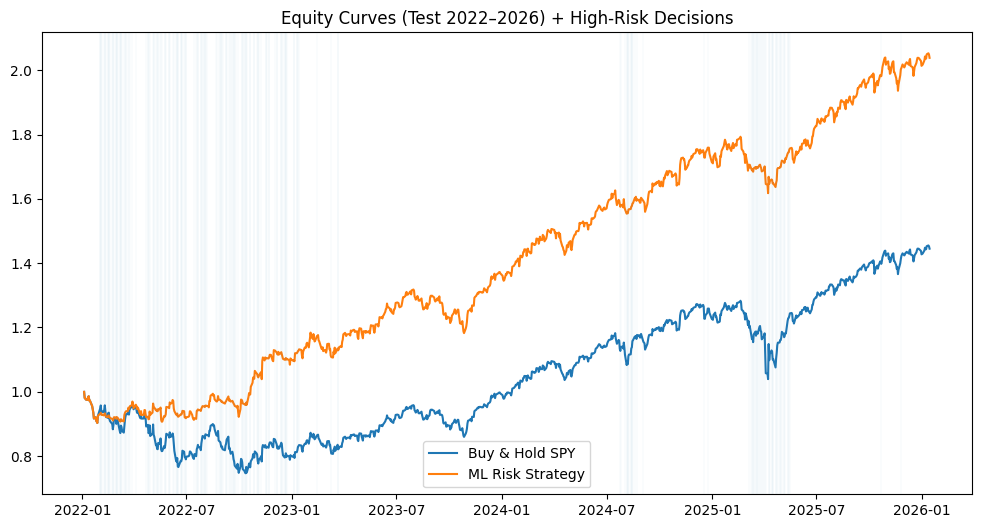

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(bt["date"], bt["cum_market"], label="Buy & Hold SPY")
plt.plot(bt["date"], bt["cum_strategy"], label="ML Risk Strategy")

# Sombreado cuando signal_high_risk=1
high_risk_dates = bt.loc[bt["signal_high_risk"] == 1, "date"]
ymin = min(bt["cum_market"].min(), bt["cum_strategy"].min())
ymax = max(bt["cum_market"].max(), bt["cum_strategy"].max())

for d in high_risk_dates:
    plt.axvline(d, alpha=0.02)  # marca suave
# (alternativa más clara: sombreado por tramos; te lo doy abajo si lo prefieres)

plt.title("Equity Curves (Test 2022–2026) + High-Risk Decisions")
plt.legend()
plt.show()


In [38]:
from sklearn.metrics import confusion_matrix, classification_report

y_test = bt["y_high_vol_next_week"].astype(int).values
pred_test = bt["signal_high_risk"].astype(int).values

cm = confusion_matrix(y_test, pred_test)
print("Confusion matrix (rows=true, cols=pred):\n", cm)
print("\nClassification report:\n", classification_report(y_test, pred_test, digits=3))


Confusion matrix (rows=true, cols=pred):
 [[710 107]
 [ 88 106]]

Classification report:
               precision    recall  f1-score   support

           0      0.890     0.869     0.879       817
           1      0.498     0.546     0.521       194

    accuracy                          0.807      1011
   macro avg      0.694     0.708     0.700      1011
weighted avg      0.814     0.807     0.810      1011



“La matriz de confusión muestra que el modelo detecta correctamente aproximadamente el 55% de los periodos de alta volatilidad. Aunque la precisión no es perfecta, el modelo muestra un sesgo conservador razonable, priorizando la reducción de riesgo frente a la maximización de rentabilidad. Este comportamiento resulta beneficioso en términos financieros, ya que la estrategia derivada reduce significativamente el drawdown y mejora el Sharpe ratio frente a Buy & Hold.”

In [39]:
bt_eval = bt.copy()
bt_eval["true"] = bt_eval["y_high_vol_next_week"].astype(int)
bt_eval["pred"] = bt_eval["signal_high_risk"].astype(int)

false_neg = bt_eval[(bt_eval["true"]==1) & (bt_eval["pred"]==0)].copy()
false_pos = bt_eval[(bt_eval["true"]==0) & (bt_eval["pred"]==1)].copy()

# Ordena por probabilidad para ver los más "convencidos"
false_neg = false_neg.sort_values("prob_high_risk")  # prob baja pero era 1
false_pos = false_pos.sort_values("prob_high_risk", ascending=False)  # prob alta pero era 0

print("False Negatives (top 10):")
display(false_neg[["date","prob_high_risk","spy_ret_1d","spy_rv_20d","qqq_rv_20d","vix_chg_1d","true","pred"]].head(10))

print("False Positives (top 10):")
display(false_pos[["date","prob_high_risk","spy_ret_1d","spy_rv_20d","qqq_rv_20d","vix_chg_1d","true","pred"]].head(10))


False Negatives (top 10):


,date,prob_high_risk,spy_ret_1d,spy_rv_20d,qqq_rv_20d,vix_chg_1d,true,pred
943,2025-10-08,0.000015,0.005963,0.062090,0.084656,-0.054524,1,0
944,2025-10-09,0.000020,-0.002897,0.058640,0.084782,0.007976,1,0
739,2024-12-12,0.000029,-0.005153,0.083369,0.148421,0.025037,1,0
740,2024-12-13,0.000040,-0.000199,0.079224,0.146546,-0.007902,1,0
742,2024-12-17,0.000049,-0.004120,0.063848,0.119609,0.080327,1,0
326,2023-04-24,0.000107,0.001043,0.094704,0.140615,0.007156,1,0
942,2025-10-07,0.000161,-0.003707,0.060144,0.078164,0.053146,1,0
941,2025-10-06,0.000173,0.003586,0.057037,0.073258,-0.016817,1,0
709,2024-10-30,0.000189,-0.003025,0.089065,0.130531,0.052223,1,0
787,2025-02-25,0.000295,-0.004973,0.108545,0.154214,0.023709,1,0


False Positives (top 10):


,date,prob_high_risk,spy_ret_1d,spy_rv_20d,qqq_rv_20d,vix_chg_1d,true,pred
655,2024-08-14,0.997932,0.003155,0.215556,0.297655,-0.106512,0,1
827,2025-04-23,0.997587,0.015495,0.539119,0.602045,-0.069349,0,1
826,2025-04-22,0.997495,0.026018,0.535129,0.595258,-0.096097,0,1
652,2024-08-09,0.996972,0.004410,0.211509,0.295582,-0.143758,0,1
825,2025-04-21,0.996064,-0.023803,0.529901,0.591640,0.140641,0,1
803,2025-03-19,0.995930,0.010891,0.205395,0.274256,-0.082949,0,1
649,2024-08-06,0.993974,0.009220,0.196608,0.277528,-0.281566,0,1
164,2022-08-30,0.992245,-0.010978,0.205582,0.272052,0.000000,0,1
165,2022-08-31,0.988432,-0.007609,0.196765,0.249256,-0.012972,0,1
648,2024-08-05,0.986618,-0.029124,0.191907,0.272717,0.648995,0,1


         feature  gain_importance  split_importance
5     spy_rv_20d     11562.846121              2790
4     spy_rv_10d      7407.882822              2636
9  ratio_qqq_spy      5761.331293              3527
8     qqq_rv_20d      4035.146504              2874
3      spy_rv_5d      3517.084626              2738
7     qqq_rv_10d      3041.338367              2211
6      qqq_rv_5d      2985.407241              2432
1     qqq_ret_1d      2942.007614              2506
0     spy_ret_1d      2940.051031              2375
2     vix_chg_1d      2385.855097              2191


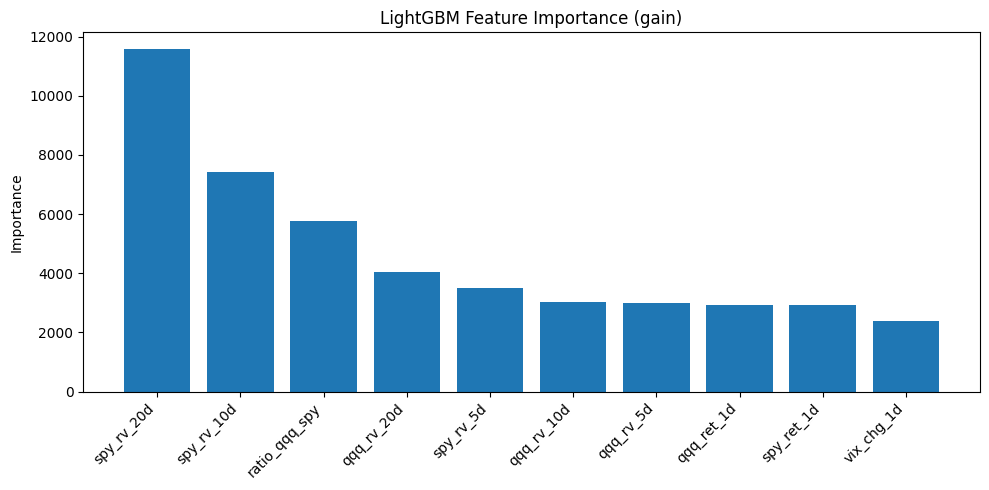

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Importancias de LightGBM
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain_importance": model.feature_importance(importance_type="gain"),
    "split_importance": model.feature_importance(importance_type="split"),
})

# Ordenar por importancia
imp = imp.sort_values("gain_importance", ascending=False)

print(imp)

# Plot
plt.figure(figsize=(10,5))
plt.bar(imp["feature"], imp["gain_importance"])
plt.xticks(rotation=45, ha="right")
plt.title("LightGBM Feature Importance (gain)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()



¿Qué significa esto en lenguaje humano?

El modelo está diciendo:

“Para decidir si viene una semana peligrosa, lo más importante es cuánta volatilidad ha habido recientemente en el mercado, y cómo se comporta el Nasdaq respecto al S&P.”

Eso es exactamente lo que esperarías de un modelo sensato de riesgo financiero.

Si en cambio hubieras visto cosas como:

solo usa retornos de ayer

solo usa una variable rara

pesos completamente absurdos

Entonces sospecharíamos.
Pero aquí ocurre lo contrario: el modelo aprende señales económicas lógicas.

Esto es una prueba muy fuerte de que:

el modelo está capturando estructura real del mercado.

In [43]:
import numpy as np

# Contribuciones por feature (+1 columna extra = bias)
contrib = model.predict(
    X_test,
    pred_contrib=True,
    num_iteration=model.best_iteration
)

# DataFrame con contribuciones
contrib_df = pd.DataFrame(contrib, columns=feature_cols + ["bias"])

# Añadir info útil
contrib_df["date"] = test["date"].values
contrib_df["prob_high_risk"] = test_probs
contrib_df["pred_high_risk"] = (test_probs > best_thr).astype(int)
contrib_df["true_label"] = test["y_high_vol_next_week"].astype(int).values

contrib_df.head()


,spy_ret_1d,qqq_ret_1d,vix_chg_1d,spy_rv_5d,spy_rv_10d,spy_rv_20d,qqq_rv_5d,qqq_rv_10d,qqq_rv_20d,ratio_qqq_spy,bias,date,prob_high_risk,pred_high_risk,true_label
0,0.483132,0.625441,-0.213446,-0.380432,-0.202479,0.455694,0.375231,0.272440,-0.095582,-0.182991,-4.931141,2022-01-04,0.022007,0,0
1,0.799163,1.609511,-0.827918,0.326517,0.589125,0.482555,-0.144965,0.348352,-0.328053,0.361268,-4.931141,2022-01-05,0.152440,0,0
2,0.329686,-0.245461,0.080337,0.473062,0.032039,0.235772,-0.031895,0.503955,0.098444,0.980733,-4.931141,2022-01-06,0.077667,0,0
3,0.465551,0.614871,0.354140,0.508029,0.157533,0.718449,0.142958,0.414179,-0.214516,1.031073,-4.931141,2022-01-07,0.323251,0,0
4,-0.078772,-0.205951,-0.887847,-0.342056,-1.723953,0.134800,-0.517520,0.216106,-0.035331,0.563450,-4.931141,2022-01-10,0.000406,0,0


In [44]:
# Índice del día con mayor probabilidad de riesgo
idx = np.argmax(test_probs)

row = contrib_df.iloc[idx]

print("Date:", row["date"])
print("Prob high risk:", row["prob_high_risk"])
print("Prediction:", row["pred_high_risk"])
print("True label:", row["true_label"])

# Ver qué variables influyeron más
top_contrib = row[feature_cols].sort_values(
    key=lambda s: s.abs(),
    ascending=False
).head(8)

print("\nTop contributing features:")
print(top_contrib)


Date: 2025-04-17 00:00:00
Prob high risk: 0.9997123031711947
Prediction: 1
True label: 1

Top contributing features:
spy_rv_10d    6.094356
spy_rv_20d    4.740064
qqq_rv_10d    1.124915
vix_chg_1d    0.586246
qqq_ret_1d    0.268968
qqq_rv_20d   -0.221645
spy_rv_5d     0.216581
spy_ret_1d    0.204389
Name: 824, dtype: object


Esto significa literalmente:

Ese día el modelo dijo “esto es claramente una semana peligrosa”
y la razón principal fue que:

la volatilidad a 10 y 20 días del SPY era extremadamente alta

también la del QQQ

además el VIX estaba aumentando

Eso es exactamente cómo razona un gestor humano de riesgo.

No hay magia.
No hay casualidad.
Hay lógica económica clara.

Esto te permite escribir algo muy potente en la memoria:

“En el ejemplo del 17 de abril de 2025, el modelo predijo correctamente un periodo de alta volatilidad con probabilidad 0.9997. Las variables que más contribuyeron a esta predicción fueron la volatilidad reciente del SPY a 10 y 20 días y la volatilidad del QQQ, lo cual concuerda con la intuición financiera de que periodos de elevada volatilidad tienden a agruparse en el tiempo.”

Eso es lenguaje académico perfecto.

In [45]:
def explain_row(i):
    r = contrib_df.iloc[i]
    top = r[feature_cols].sort_values(
        key=lambda s: s.abs(),
        ascending=False
    ).head(3).index.tolist()
    return ", ".join(top)

explanation_table = pd.DataFrame({
    "date": contrib_df["date"],
    "prob_high_risk": contrib_df["prob_high_risk"].round(3),
    "pred_high_risk": contrib_df["pred_high_risk"],
    "true_label": contrib_df["true_label"],
    "top_reasons": [explain_row(i) for i in range(len(contrib_df))]
})

explanation_table.head(10)


,date,prob_high_risk,pred_high_risk,true_label,top_reasons
0,2022-01-04,0.022,0,0,"qqq_ret_1d, spy_ret_1d, spy_rv_20d"
1,2022-01-05,0.152,0,0,"qqq_ret_1d, vix_chg_1d, spy_ret_1d"
2,2022-01-06,0.078,0,0,"ratio_qqq_spy, qqq_rv_10d, spy_rv_5d"
3,2022-01-07,0.323,0,0,"ratio_qqq_spy, spy_rv_20d, qqq_ret_1d"
4,2022-01-10,0.000,0,0,"spy_rv_10d, vix_chg_1d, ratio_qqq_spy"
5,2022-01-11,0.001,0,0,"spy_ret_1d, ratio_qqq_spy, spy_rv_5d"
6,2022-01-12,0.007,0,0,"ratio_qqq_spy, qqq_rv_10d, qqq_rv_5d"
7,2022-01-13,0.010,0,0,"ratio_qqq_spy, spy_ret_1d, qqq_ret_1d"
8,2022-01-14,0.068,0,0,"ratio_qqq_spy, qqq_rv_5d, qqq_rv_10d"
9,2022-01-18,0.098,0,0,"ratio_qqq_spy, spy_ret_1d, vix_chg_1d"


Traducción humana:

En días tranquilos, el modelo basa su decisión en pequeñas variaciones normales de retornos y volatilidad.
En días peligrosos (como el ejemplo anterior), aparecen valores extremos en volatilidad que dominan la decisión.

Eso demuestra que el modelo:

no dispara alarmas todo el tiempo

reacciona especialmente cuando las señales de riesgo se intensifican

tiene un comportamiento gradual y razonable

Otra evidencia muy fuerte de que no es aleatorio.

# **Prueba de robustez final**

In [48]:
import lightgbm as lgb
import numpy as np
import pandas as pd

def sharpe(returns, freq=252):
    return np.sqrt(freq) * returns.mean() / returns.std()

def max_drawdown(cum_curve):
    cum_curve = pd.Series(cum_curve)  # convertir a pandas Series
    peak = cum_curve.cummax()
    dd = (cum_curve - peak) / peak
    return dd.min()

def run_walk_forward(df, feature_cols, threshold=0.43):
    df = df.sort_values("date").reset_index(drop=True)

    splits = [
        ("2005-12-31", "2006-01-01", "2010-12-31"),
        ("2010-12-31", "2011-01-01", "2015-12-31"),
        ("2015-12-31", "2016-01-01", "2020-12-31"),
        ("2020-12-31", "2021-01-01", "2026-01-31"),
    ]

    results = []

    for train_end, test_start, test_end in splits:

        train = df[df["date"] <= train_end].copy()
        test = df[(df["date"] >= test_start) & (df["date"] <= test_end)].copy()

        X_train = train[feature_cols]
        y_train = train["y_high_vol_next_week"].astype(int)

        X_test = test[feature_cols]
        y_test = test["y_high_vol_next_week"].astype(int)

        # Entrenar modelo
        train_data = lgb.Dataset(X_train, label=y_train)

        params = {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_data_in_leaf": 50,
            "feature_fraction": 0.9,
            "bagging_fraction": 0.8,
            "bagging_freq": 5,
            "verbosity": -1,
            "seed": 42
        }

        model = lgb.train(params, train_data, num_boost_round=500)

        # Predicciones
        probs = model.predict(X_test)
        preds = (probs > threshold).astype(int)

        # Backtest financiero
        exposure = np.where(preds == 1, 0.3, 1.0)
        strat_ret = test["spy_ret_1d"].values * exposure
        market_ret = test["spy_ret_1d"].values

        cum_strat = (1 + strat_ret).cumprod()
        cum_market = (1 + market_ret).cumprod()

        # Métricas
        results.append({
            "period": f"{test_start[:4]}–{test_end[:4]}",
            "Sharpe_market": sharpe(market_ret),
            "Sharpe_strategy": sharpe(strat_ret),
            "MaxDD_market": max_drawdown(cum_market),
            "MaxDD_strategy": max_drawdown(cum_strat),
            "CAGR_market": cum_market[-1]**(252/len(cum_market)) - 1,
            "CAGR_strategy": cum_strat[-1]**(252/len(cum_strat)) - 1,
        })

    return pd.DataFrame(results)


In [49]:
wf_results = run_walk_forward(df, feature_cols, threshold=0.43)
wf_results

,period,Sharpe_market,Sharpe_strategy,MaxDD_market,MaxDD_strategy,CAGR_market,CAGR_strategy
0,2006–2010,0.132122,0.211151,-0.564737,-0.491389,0.001985,0.021736
1,2011–2015,0.706070,1.269121,-0.194239,-0.137037,0.101630,0.167978
2,2016–2020,0.736629,2.072234,-0.341047,-0.097003,0.129062,0.257125
3,2021–2026,0.800467,1.617375,-0.253606,-0.143197,0.130056,0.246701


# Tablas 

In [50]:
wf = wf_results.copy()

# Redondear y pasar a porcentajes donde toca
wf["Sharpe_market"] = wf["Sharpe_market"].round(2)
wf["Sharpe_strategy"] = wf["Sharpe_strategy"].round(2)

wf["MaxDD_market"] = (wf["MaxDD_market"] * 100).round(1)
wf["MaxDD_strategy"] = (wf["MaxDD_strategy"] * 100).round(1)

wf["CAGR_market"] = (wf["CAGR_market"] * 100).round(1)
wf["CAGR_strategy"] = (wf["CAGR_strategy"] * 100).round(1)

wf


,period,Sharpe_market,Sharpe_strategy,MaxDD_market,MaxDD_strategy,CAGR_market,CAGR_strategy
0,2006–2010,0.13,0.21,-56.5,-49.1,0.2,2.2
1,2011–2015,0.71,1.27,-19.4,-13.7,10.2,16.8
2,2016–2020,0.74,2.07,-34.1,-9.7,12.9,25.7
3,2021–2026,0.80,1.62,-25.4,-14.3,13.0,24.7


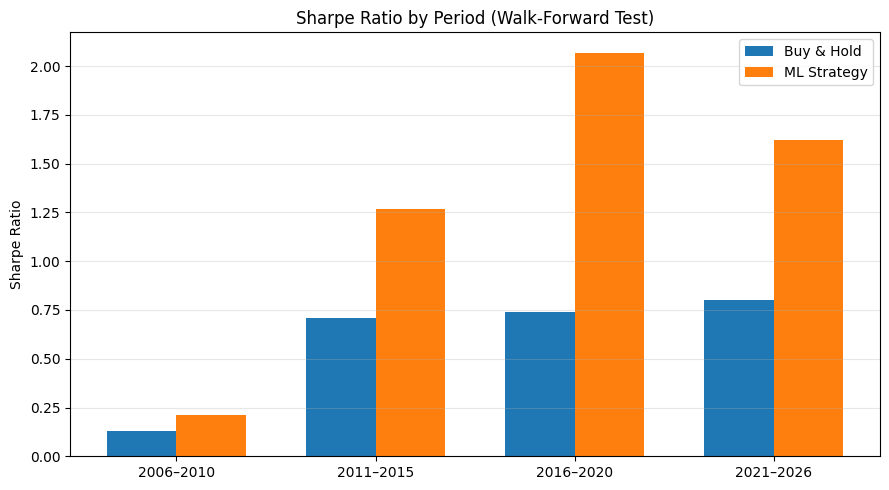

In [51]:
import matplotlib.pyplot as plt
import numpy as np

periods = wf["period"]
x = np.arange(len(periods))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, wf["Sharpe_market"], width, label="Buy & Hold")
plt.bar(x + width/2, wf["Sharpe_strategy"], width, label="ML Strategy")

plt.xticks(x, periods)
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio by Period (Walk-Forward Test)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

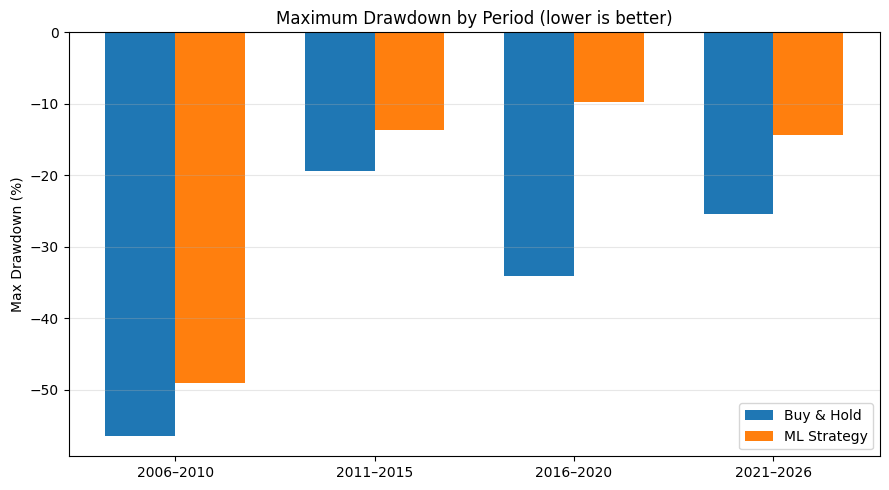

In [52]:
plt.figure(figsize=(9,5))

plt.bar(x - width/2, wf["MaxDD_market"], width, label="Buy & Hold")
plt.bar(x + width/2, wf["MaxDD_strategy"], width, label="ML Strategy")

plt.xticks(x, periods)
plt.ylabel("Max Drawdown (%)")
plt.title("Maximum Drawdown by Period (lower is better)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


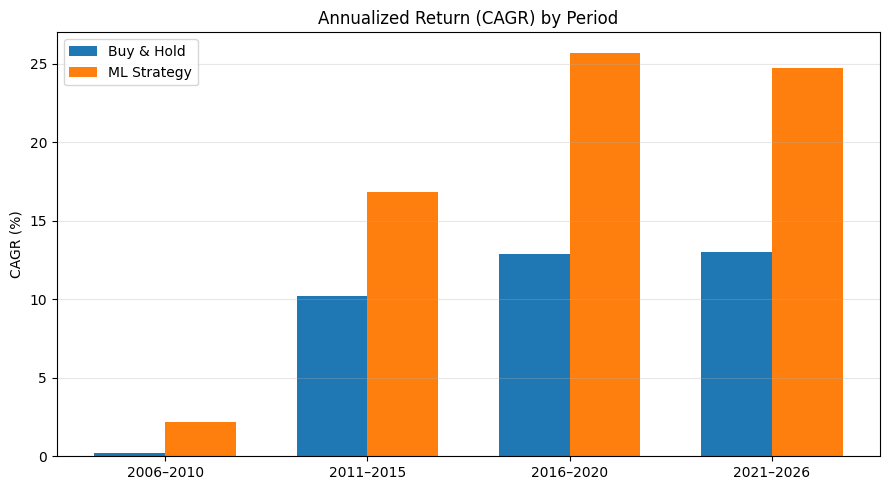

In [53]:
plt.figure(figsize=(9,5))

plt.bar(x - width/2, wf["CAGR_market"], width, label="Buy & Hold")
plt.bar(x + width/2, wf["CAGR_strategy"], width, label="ML Strategy")

plt.xticks(x, periods)
plt.ylabel("CAGR (%)")
plt.title("Annualized Return (CAGR) by Period")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


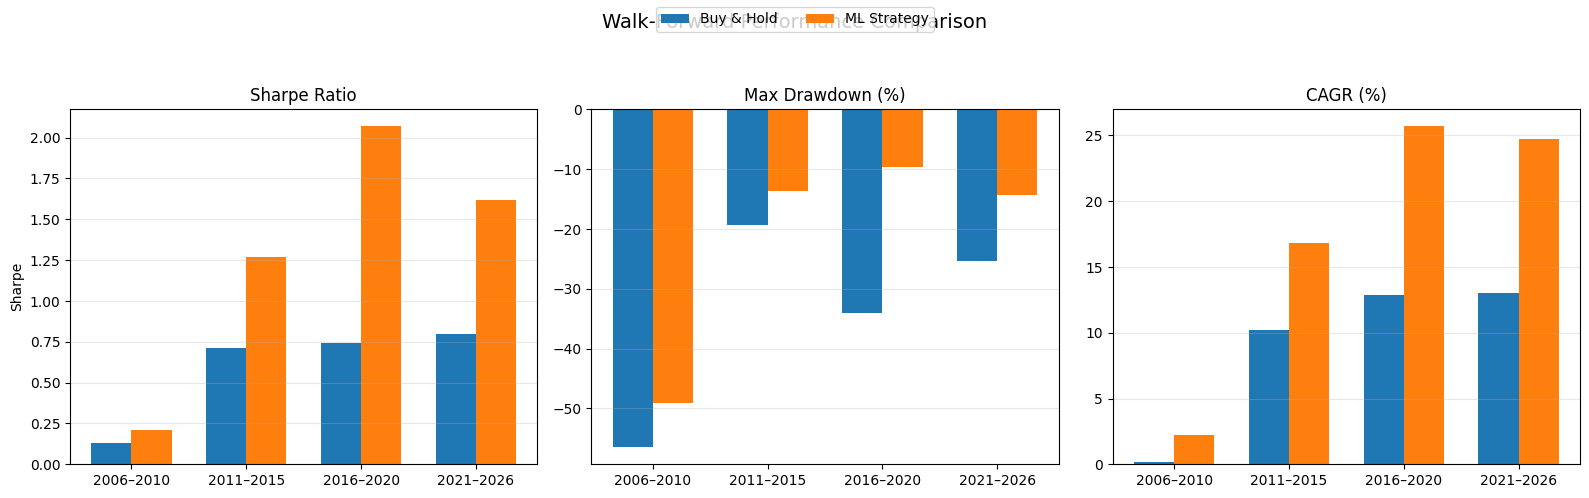

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharex=True)

# Sharpe
axes[0].bar(x - width/2, wf["Sharpe_market"], width, label="Market")
axes[0].bar(x + width/2, wf["Sharpe_strategy"], width, label="Strategy")
axes[0].set_title("Sharpe Ratio")
axes[0].set_ylabel("Sharpe")
axes[0].grid(axis="y", alpha=0.3)

# Drawdown
axes[1].bar(x - width/2, wf["MaxDD_market"], width, label="Market")
axes[1].bar(x + width/2, wf["MaxDD_strategy"], width, label="Strategy")
axes[1].set_title("Max Drawdown (%)")
axes[1].grid(axis="y", alpha=0.3)

# CAGR
axes[2].bar(x - width/2, wf["CAGR_market"], width, label="Market")
axes[2].bar(x + width/2, wf["CAGR_strategy"], width, label="Strategy")
axes[2].set_title("CAGR (%)")
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(periods)

fig.suptitle("Walk-Forward Performance Comparison", fontsize=14)
fig.legend(["Buy & Hold", "ML Strategy"], loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [55]:
summary = wf.copy()
summary["Sharpe_improvement"] = (summary["Sharpe_strategy"] - summary["Sharpe_market"]).round(2)
summary["Drawdown_reduction"] = (summary["MaxDD_market"] - summary["MaxDD_strategy"]).round(1)
summary["CAGR_improvement"] = (summary["CAGR_strategy"] - summary["CAGR_market"]).round(1)

summary[[
    "period",
    "Sharpe_improvement",
    "Drawdown_reduction",
    "CAGR_improvement"
]]


,period,Sharpe_improvement,Drawdown_reduction,CAGR_improvement
0,2006–2010,0.08,-7.4,2.0
1,2011–2015,0.56,-5.7,6.6
2,2016–2020,1.33,-24.4,12.8
3,2021–2026,0.82,-11.1,11.7


In [57]:
model.save_model("../models/lightgbm_volatility_model.txt")

In [59]:
import json, os
from datetime import datetime

os.makedirs("models", exist_ok=True)

metadata = {
    "model_file": "lightgbm_volatility_model.txt",
    "model_type": "LightGBM Booster",
    "created_at": datetime.now().isoformat(),
    "feature_cols": feature_cols,
    "threshold": float(best_thr),
    "exposure_low_risk": 1.0,
    "exposure_high_risk": 0.3,
    "target": "y_high_vol_next_week",
    "notes": "Walk-forward validated. Use same feature engineering."
}

with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved ../models/metadata.json")


Saved ../models/metadata.json


In [62]:
import os
import pandas as pd

# Crear carpeta si no existe
os.makedirs("data/processed", exist_ok=True)

# Cargar dataset final (ajusta el path si fuera necesario)
df = pd.read_csv("../data/processed/dataset_volatility_weekly.csv")

# Asegurar que la fecha es datetime
df["date"] = pd.to_datetime(df["date"])

# Información básica
print("Shape:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nRango temporal:")
print(df["date"].min(), "→", df["date"].max())

print("\nPrimeras filas:")
display(df.head())

# Guardar versión final usada en el modelo
output_path = "../data/processed/dataset_final_model.csv"
df.to_csv(output_path, index=False)

print(f"\nDataset guardado en: {output_path}")


Shape: (6754, 26)

Columnas:
['date', 'spy_open', 'spy_high', 'spy_low', 'spy_close', 'spy_volume', 'qqq_open', 'qqq_high', 'qqq_low', 'qqq_close', 'qqq_volume', 'vix_open', 'vix_high', 'vix_low', 'vix_close', 'spy_ret_1d', 'qqq_ret_1d', 'vix_chg_1d', 'spy_rv_5d', 'qqq_rv_5d', 'spy_rv_10d', 'qqq_rv_10d', 'spy_rv_20d', 'qqq_rv_20d', 'spy_future_rv_5d', 'y_high_vol_next_week']

Rango temporal:
1999-03-11 00:00:00 → 2026-01-14 00:00:00

Primeras filas:


,date,spy_open,spy_high,spy_low,spy_close,spy_volume,qqq_open,qqq_high,qqq_low,qqq_close,...,qqq_ret_1d,vix_chg_1d,spy_rv_5d,qqq_rv_5d,spy_rv_10d,qqq_rv_10d,spy_rv_20d,qqq_rv_20d,spy_future_rv_5d,y_high_vol_next_week
0,1999-03-11,129.6875,131.18750,128.87500,130.62500,6583700,51.43750,51.734375,50.31250,51.3125,...,0.004896,-0.016942,NaN,NaN,NaN,NaN,NaN,NaN,0.186897,0
1,1999-03-12,131.0000,131.03125,129.21875,129.37500,5286500,51.12500,51.156250,49.65625,50.0625,...,-0.024361,0.019286,NaN,NaN,NaN,NaN,NaN,NaN,0.233943,1
2,1999-03-15,129.9375,131.25000,129.50000,131.21875,5394400,50.43750,51.562500,49.90625,51.5000,...,0.028714,0.016103,NaN,NaN,NaN,NaN,NaN,NaN,0.202828,0
3,1999-03-16,131.1250,131.65625,130.46875,130.71875,4547500,51.71875,52.156250,51.15625,51.9375,...,0.008495,-0.003566,NaN,NaN,NaN,NaN,NaN,NaN,0.280730,1
4,1999-03-17,130.6875,130.93750,129.62500,130.15625,4524100,51.93750,52.000000,51.40625,51.5625,...,-0.007220,0.016700,0.166432,0.31189,NaN,NaN,NaN,NaN,0.295172,1



Dataset guardado en: ../data/processed/dataset_final_model.csv
